# Notebook 01: Data Collection & Exploratory Data Analysis

This notebook downloads cricket match data from Cricsheet.org, parses it, and performs initial EDA.

**Formats covered:**
- Men's ODI
- Women's ODI
- Men's T20I
- Women's T20I

In [3]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

from src.data_collection import collect_all, collect_format, load_processed, CRICSHEET_URLS
from src.visualizations import plot_eda_score_distribution

print('Formats available:', list(CRICSHEET_URLS.keys()))

Formats available: ['mens_odi', 'womens_odi', 'mens_t20i', 'womens_t20i']


## 1.1 Download & Parse Data

Download ball-by-ball JSON data from cricsheet.org for all 4 formats.

In [4]:
# Download and parse all formats
# This may take several minutes depending on internet speed
all_data = collect_all()

for fmt, (matches_df, deliveries_df) in all_data.items():
    print(f"\n{fmt}:")
    print(f"  Matches: {len(matches_df)}")
    print(f"  Deliveries: {len(deliveries_df)}")

2026-02-05 22:44:01,717 - INFO - ============================================================
2026-02-05 22:44:01,719 - INFO - Processing: mens_odi
2026-02-05 22:44:01,719 - INFO - ============================================================
2026-02-05 22:44:02,062 - INFO - [mens_odi] Already have 3085 JSON files. Skipping download.
2026-02-05 22:44:02,120 - INFO - [mens_odi] Parsing 3085 match files...
Parsing mens_odi: 100%|██████████| 3085/3085 [00:10<00:00, 283.28it/s]
2026-02-05 22:44:23,639 - INFO - [mens_odi] Parsed 3085 matches, 1632502 deliveries.
2026-02-05 22:44:25,536 - INFO - [mens_odi] Saved to mens_odi_matches.parquet (3085 rows) and mens_odi_deliveries.parquet (1632502 rows)
2026-02-05 22:44:25,537 - INFO - ============================================================
2026-02-05 22:44:25,538 - INFO - Processing: womens_odi
2026-02-05 22:44:25,539 - INFO - ============================================================
2026-02-05 22:44:25,540 - INFO - [womens_odi] Downloadin

HTTPError: 404 Client Error: Not Found for url: https://cricsheet.org/downloads/wodis_json.zip

## 1.2 Data Overview - Men's ODI

In [5]:
matches_df, deliveries_df = load_processed('mens_odi')

print(f"Total matches: {len(matches_df)}")
print(f"Total deliveries: {len(deliveries_df)}")
print(f"Date range: {matches_df['date'].min()} to {matches_df['date'].max()}")
print(f"\nMatch columns: {list(matches_df.columns)}")
print(f"\nDelivery columns: {list(deliveries_df.columns)}")

Total matches: 3085
Total deliveries: 1632502
Date range: 2002-06-27 00:00:00 to 2026-01-27 00:00:00

Match columns: ['match_id', 'date', 'venue', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'margin_runs', 'margin_wickets', 'method', 'result', 'match_type', 'gender', 'overs_limit', 'player_of_match']

Delivery columns: ['match_id', 'innings', 'batting_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batter_runs', 'extras_runs', 'total_runs', 'is_wicket', 'dismissal_kind', 'player_out', 'is_wide', 'is_noball', 'is_boundary_four', 'is_boundary_six']


In [6]:
matches_df.head()

,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner,margin_runs,margin_wickets,method,result,match_type,gender,overs_limit,player_of_match
0,1000887,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",Brisbane,Australia,Pakistan,Australia,bat,Australia,92.0,NaN,NaN,NaN,ODI,male,50,MS Wade
1,1000889,2017-01-15,Melbourne Cricket Ground,NaN,Australia,Pakistan,Australia,bat,Pakistan,NaN,6.0,NaN,NaN,ODI,male,50,Mohammad Hafeez
2,1000891,2017-01-19,Western Australia Cricket Association Ground,Perth,Australia,Pakistan,Australia,field,Australia,NaN,7.0,NaN,NaN,ODI,male,50,SPD Smith
3,1000893,2017-01-22,Sydney Cricket Ground,NaN,Australia,Pakistan,Australia,bat,Australia,86.0,NaN,NaN,NaN,ODI,male,50,DA Warner
4,1000895,2017-01-26,Adelaide Oval,NaN,Australia,Pakistan,Australia,bat,Australia,57.0,NaN,NaN,NaN,ODI,male,50,DA Warner


In [7]:
deliveries_df.head(10)

,match_id,innings,batting_team,over,ball,batter,bowler,non_striker,batter_runs,extras_runs,total_runs,is_wicket,dismissal_kind,player_out,is_wide,is_noball,is_boundary_four,is_boundary_six
0,1000887,1,Australia,0,0,DA Warner,Mohammad Amir,TM Head,0,0,0,False,NaN,NaN,False,False,False,False
1,1000887,1,Australia,0,1,DA Warner,Mohammad Amir,TM Head,0,0,0,False,NaN,NaN,False,False,False,False
2,1000887,1,Australia,0,2,DA Warner,Mohammad Amir,TM Head,0,0,0,False,NaN,NaN,False,False,False,False
3,1000887,1,Australia,0,3,DA Warner,Mohammad Amir,TM Head,0,0,0,False,NaN,NaN,False,False,False,False
4,1000887,1,Australia,0,4,DA Warner,Mohammad Amir,TM Head,0,1,1,False,NaN,NaN,True,False,False,False
5,1000887,1,Australia,0,5,DA Warner,Mohammad Amir,TM Head,0,0,0,False,NaN,NaN,False,False,False,False
6,1000887,1,Australia,0,6,DA Warner,Mohammad Amir,TM Head,0,0,0,False,NaN,NaN,False,False,False,False
7,1000887,1,Australia,1,0,TM Head,Mohammad Hafeez,DA Warner,0,0,0,False,NaN,NaN,False,False,False,False
8,1000887,1,Australia,1,1,TM Head,Mohammad Hafeez,DA Warner,1,0,1,False,NaN,NaN,False,False,False,False
9,1000887,1,Australia,1,2,DA Warner,Mohammad Hafeez,TM Head,0,0,0,False,NaN,NaN,False,False,False,False


## 1.3 D/L Method Usage

In [8]:
# D/L method usage stats
dl_count = matches_df['method'].notna().sum()
no_result = (matches_df['result'] == 'no result').sum()
completed = len(matches_df) - dl_count - no_result

print(f"Completed (no D/L): {completed}")
print(f"D/L applied: {dl_count}")
print(f"No result: {no_result}")
print(f"\nD/L percentage: {dl_count / len(matches_df) * 100:.1f}%")

Completed (no D/L): 2709
D/L applied: 257
No result: 119

D/L percentage: 8.3%


## 1.4 Exploratory Data Analysis

In [9]:
# Generate EDA plots
plot_eda_score_distribution(matches_df, deliveries_df, 'mens_odi')
print("EDA plots saved to results/figures/")

2026-02-05 22:45:19,154 - INFO - Saved: /Users/akshma/Downloads/rajat_thesis/results/figures/mens_odi_eda.png


EDA plots saved to results/figures/


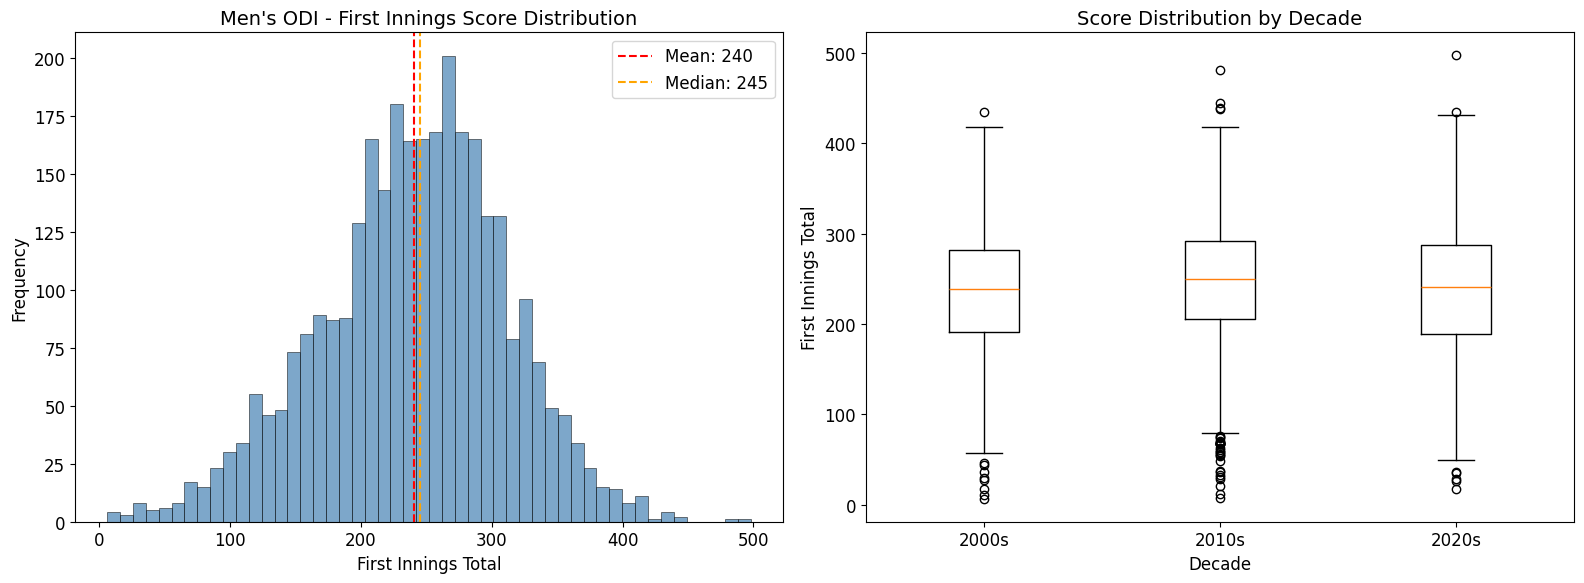


Score Statistics:
count    3085.000000
mean      240.200324
std        71.503436
min         6.000000
25%       197.000000
50%       245.000000
75%       288.000000
max       498.000000
Name: total_runs, dtype: float64


In [10]:
# Inline EDA: First innings score distribution
first_inn = deliveries_df[deliveries_df['innings'] == 1]
totals = first_inn.groupby('match_id')['total_runs'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(totals, bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(totals.mean(), color='red', linestyle='--', label=f'Mean: {totals.mean():.0f}')
axes[0].axvline(totals.median(), color='orange', linestyle='--', label=f'Median: {totals.median():.0f}')
axes[0].set_xlabel('First Innings Total')
axes[0].set_ylabel('Frequency')
axes[0].set_title("Men's ODI - First Innings Score Distribution")
axes[0].legend()

# Box plot of scores by decade
match_totals = totals.reset_index()
match_totals.columns = ['match_id', 'total']
match_totals = match_totals.merge(matches_df[['match_id', 'date']], on='match_id')
match_totals['decade'] = (pd.to_datetime(match_totals['date']).dt.year // 10) * 10

decades = sorted(match_totals['decade'].dropna().unique())
decade_data = [match_totals[match_totals['decade'] == d]['total'].values for d in decades]
axes[1].boxplot(decade_data, labels=[str(int(d)) + 's' for d in decades])
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('First Innings Total')
axes[1].set_title('Score Distribution by Decade')

plt.tight_layout()
plt.show()

print(f"\nScore Statistics:")
print(totals.describe())

In [11]:
# Top venues
print("Top 15 Venues:")
print(matches_df['venue'].value_counts().head(15))

Top 15 Venues:
venue
Harare Sports Club                         124
Shere Bangla National Stadium               85
Dubai International Cricket Stadium         59
Rangiri Dambulla International Stadium      51
Sydney Cricket Ground                       49
R Premadasa Stadium                         49
R Premadasa Stadium, Colombo                45
Kennington Oval                             42
Pallekele International Cricket Stadium     42
County Ground                               41
Melbourne Cricket Ground                    40
Sheikh Zayed Stadium                        37
Queens Sports Club                          37
Adelaide Oval                               34
Lord's                                      34
Name: count, dtype: int64


In [12]:
# Top teams
team_counts = pd.concat([matches_df['team1'], matches_df['team2']]).value_counts()
print("Top 15 Teams by appearances:")
print(team_counts.head(15))

Top 15 Teams by appearances:
India                       648
Australia                   589
England                     581
Sri Lanka                   572
South Africa                536
Pakistan                    519
New Zealand                 501
West Indies                 483
Bangladesh                  380
Zimbabwe                    305
Ireland                     196
Scotland                    124
United Arab Emirates        117
Netherlands                 104
United States of America     80
Name: count, dtype: int64


## 1.5 Summary Statistics for Other Formats

In [13]:
# Summary for all formats
for fmt in ['womens_odi', 'mens_t20i', 'womens_t20i']:
    try:
        m, d = load_processed(fmt)
        first = d[d['innings'] == 1]
        totals = first.groupby('match_id')['total_runs'].sum()
        print(f"\n{'='*50}")
        print(f"{fmt}:")
        print(f"  Matches: {len(m)}")
        print(f"  Deliveries: {len(d)}")
        print(f"  Avg 1st innings: {totals.mean():.1f}")
        print(f"  Median 1st innings: {totals.median():.0f}")
        print(f"  Date range: {m['date'].min()} to {m['date'].max()}")
        
        # Also generate EDA plots
        plot_eda_score_distribution(m, d, fmt)
    except FileNotFoundError:
        print(f"\n{fmt}: Data not yet collected")


womens_odi: Data not yet collected

mens_t20i: Data not yet collected

womens_t20i: Data not yet collected


## 1.6 Data Quality Checks

In [14]:
# Check for data quality issues
matches_df, deliveries_df = load_processed('mens_odi')

print("Missing values in matches:")
print(matches_df.isnull().sum())
print(f"\nMissing values in deliveries:")
print(deliveries_df.isnull().sum())

# Verify innings structure
inn_counts = deliveries_df.groupby('match_id')['innings'].nunique()
print(f"\nMatches with 1 innings: {(inn_counts == 1).sum()}")
print(f"Matches with 2 innings: {(inn_counts == 2).sum()}")
print(f"Matches with >2 innings: {(inn_counts > 2).sum()}")

Missing values in matches:
match_id              0
date                  0
venue                 0
city                306
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner              153
margin_runs        1654
margin_wickets     1584
method             2828
result             2932
match_type            0
gender                0
overs_limit           0
player_of_match     219
dtype: int64

Missing values in deliveries:
match_id                  0
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
batter_runs               0
extras_runs               0
total_runs                0
is_wicket                 0
dismissal_kind      1587823
player_out          1587823
is_wide                   0
is_noball                 0
is_boundary_four          0
is_boundary_six           0
dtype: int64

Mat

In [15]:
print("\n✓ Data collection and EDA complete!")
print("Parquet files saved in data/processed/")
print("EDA figures saved in results/figures/")


✓ Data collection and EDA complete!
Parquet files saved in data/processed/
EDA figures saved in results/figures/
